In [1]:
import numpy as np
import matplotlib.pyplot as plt
from helpers import compute_N
from tqdm import tqdm

In [2]:
# Set the constants
T0 = 1.0                      # planar channel temperature
Uw = 0.1                      # wall velocity
Np = 50000                    # particles 
L = 1.0                       # distance between plates 
Tw = 1.0                      # wall temperature
m = 1.0                       # mass of argon 
k = 1.0                       # Boltzmann constant
tau = 0.05                    # relaxation time 
t = 0                         # initial time
t_end = 5                     # final time
dt = 0.001                    # timestep
Nsteps = int(t_end // dt) + 1 # number of steps
Nc = 10                       # number of cells
dx = L / Nc                   # space grid length
Tbar = 1.0                    # Correlated 

In [3]:
def compute_cell_moments(M, cell_index, Nc, Mbar=None, Ubar=None):
    """
    Compute cell-averaged mean velocity and temperature for N_c cells.

    Parameters
    ----------
    M : ndarray, shape (Np, 3)
        Particle velocities.
    cell_index : ndarray, shape (Np,)
        Cell index for each particle.
    Nc : int
        Number of cells.
    m : float
        Particle mass.
    k : float
        Boltzmann constant.
    Mbar : ndarray, shape (Np, 3), optional
        Correlated/reference particle velocities (baseline).
        If provided, used for variance reduction: M_corrected = M - Mbar + Ubar[cell_index]
    Ubar : ndarray, shape (Nc, 3), optional
        Cell-averaged expected values of Mbar (for baseline correction).
        Required if Mbar is provided.

    Returns
    -------
    U : ndarray, shape (Nc, 3)
        Mean velocity in each cell.
    T : ndarray, shape (Nc,)
        Temperature in each cell.
    """    
    U = np.zeros((Nc, 3))
    T = np.zeros(Nc)

    if Mbar is not None:
        if Ubar is None:
            raise ValueError("If Mbar is provided, Ubar must also be provided")
        M_corrected = M - Mbar + Ubar[cell_index]
    else:
        M_corrected = M

    for c in range(Nc):
        mask = cell_index == c
        if mask.any():
            V_cell = M_corrected[mask]

            # Mean velocity
            U[c] = V_cell.mean(axis=0)

            # Temperature
            T[c] = (m / (3 * k)) * ((V_cell - U[c])**2).sum(axis=1).mean()
    return U, T

In [4]:
def evolve_velocity_M(M, mask, U_cell, T_cell, dt, tau, m, k, noise):
    M[mask] = (M[mask] - U_cell) * np.exp(-dt/tau) + U_cell + np.sqrt((k * T_cell / m) * (1 - np.exp(-2*dt/tau))) * noise

def evolve_velocity_Mbar(Mbar, N, mask, dt, tau, m, k, Tbar, noise):
    """
    Evolve the correlated process Mbar using variance-reduced scheme.
    Mbar: Np x 3 array
    N: Np x 3 array, drift for each particle
    mask: boolean array for selected particles
    """
    Ni_sq_mean = np.mean(N[mask]**2, axis=0)  

    Mbar[mask] = np.exp(-dt/tau) * Mbar[mask] \
                 + dt * N[mask] \
                 + np.sqrt(np.maximum((k*Tbar/m) * (1 - np.exp(-2*dt/tau)) - dt**2 * Ni_sq_mean, 0.0)) * noise

In [5]:
def apply_wall_bc(X, M, Mbar, L, Tw, Uw, m, k, Tbar):
    # Left wall
    left_mask = X < -L/2
    if left_mask.any():
        # Reflect particle back to boundary
        X[left_mask] = -L/2
        # Re-sample velocity
        N_left = left_mask.sum()
        r1_left = np.random.uniform(size=N_left)
        r2_left = np.random.uniform(size=N_left)
        r3_left = np.random.uniform(size=N_left)
        M[left_mask, 0] = np.sqrt(-2*k*Tw/m * np.log(r1_left))
        M[left_mask, 1] = np.sqrt(-2*k*Tw/m * np.log(r2_left)) * np.sin(2*np.pi*r3_left) + Uw
        M[left_mask, 2] = np.sqrt(-2*k*Tw/m * np.log(r2_left)) * np.cos(2*np.pi*r3_left)

    # Right wall
    right_mask = X > L/2
    if right_mask.any():
        X[right_mask] = L/2
        N_right = right_mask.sum()
        r1_right = np.random.uniform(size=N_right)
        r2_right = np.random.uniform(size=N_right)
        r3_right = np.random.uniform(size=N_right)
        M[right_mask, 0] = -np.sqrt(-2*k*Tw/m * np.log(r1_right))
        M[right_mask, 1] = np.sqrt(-2*k*Tw/m * np.log(r2_right)) * np.sin(2*np.pi*r3_right) - Uw
        M[right_mask, 2] = np.sqrt(-2*k*Tw/m * np.log(r2_right)) * np.cos(2*np.pi*r3_right)


    return left_mask, right_mask

In [6]:
# Implementation of Algorithm 1 
X = np.random.uniform(low=-L/2, high=L/2, size=Np) 

r1 = np.random.uniform(size=Np) 
r2 = np.random.uniform(size=Np) 
r3 = np.random.uniform(size=Np) 
r4 = np.random.uniform(size=Np) 

M = np.zeros((Np, 3)) 
M[:, 0] = np.sqrt(-2 * k * T0 / m * np.log(r1)) * np.cos(2 * np.pi * r2) 
M[:, 1] = np.sqrt(-2 * k * T0 / m * np.log(r3)) * np.sin(2 * np.pi * r4) 
M[:, 2] = np.sqrt(-2 * k * T0 / m * np.log(r3)) * np.cos(2 * np.pi * r4) 

# Mbar: use same r's for correlation
Mbar = np.zeros((Np, 3)) 

Mbar[:, 0] = np.sqrt(-2 * k * Tbar / m * np.log(r1)) * np.cos(2*np.pi*r2)
Mbar[:, 1] = np.sqrt(-2 * k * Tbar / m * np.log(r3)) * np.sin(2*np.pi*r4)
Mbar[:, 2] = np.sqrt(-2 * k * Tbar / m * np.log(r3)) * np.cos(2*np.pi*r4)

U = np.zeros((Nsteps, Nc, 3)) 
T = np.zeros([Nsteps, Nc]) 

Ubar = np.zeros((Nc, 3))

cell_index = np.floor((X + L/2) / dx).astype(int) 
cell_index = np.clip(cell_index, 0, Nc-1) # make sure no particle is out of bounds 
U[0], T[0] = compute_cell_moments(M, cell_index, Nc, Mbar, Ubar)

for step in tqdm(range(1, Nsteps)):
    #print(f"Step {step}: max|Mbar| = {np.abs(Mbar).max():.4f}, max|M| = {np.abs(M).max():.4f}")

    # Evolve X^i 
    X = X + dt * M[:, 0] 
    
    # Apply B.C. 
    left_mask, right_mask = apply_wall_bc(X, M, Mbar, L, Tw, Uw, m, k, Tbar) 
    mask_wall = left_mask | right_mask # particles that just hit wall 

    # Sort particles 
    cell_index = np.floor((X + L/2) / dx).astype(int) 
    cell_index = np.clip(cell_index, 0, Nc-1) # make sure no particle is out of bounds
    N = compute_N(M, Mbar, U[step-1], Nc, X, L, dx, m, k, Tbar, tau)

    for c in range(Nc): 
        mask_c = (cell_index==c) 
        mask_c_update = mask_c & (~mask_wall) # exclude wall-hitting particles, because they are already handled  
        if mask_c_update.any(): 
            # Evolve V^i
            noise = np.random.normal(0,1,size=M[mask_c_update].shape) # Common noise
            evolve_velocity_M(M, mask_c_update, U[step-1, c], T[step-1, c], dt, tau, m, k, noise)
            evolve_velocity_Mbar(Mbar, N, mask_c_update, dt, tau, m, k, Tbar, noise) 
      
    U[step], T[step] = compute_cell_moments(M, cell_index, Nc, Mbar, Ubar)

100%|███████████████████████████████████████| 4999/4999 [13:19<00:00,  6.25it/s]


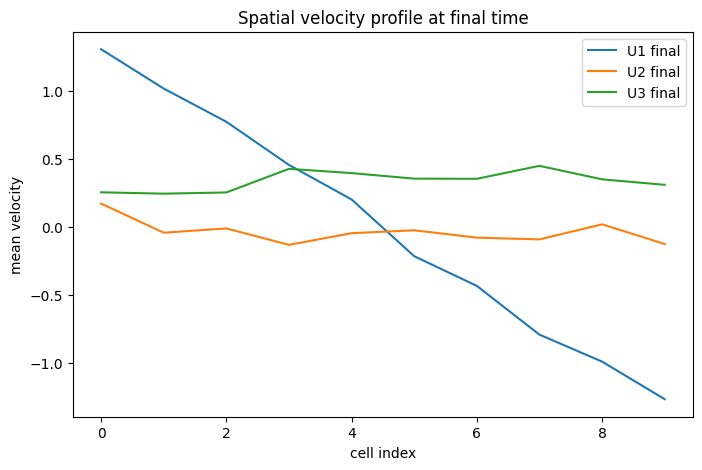

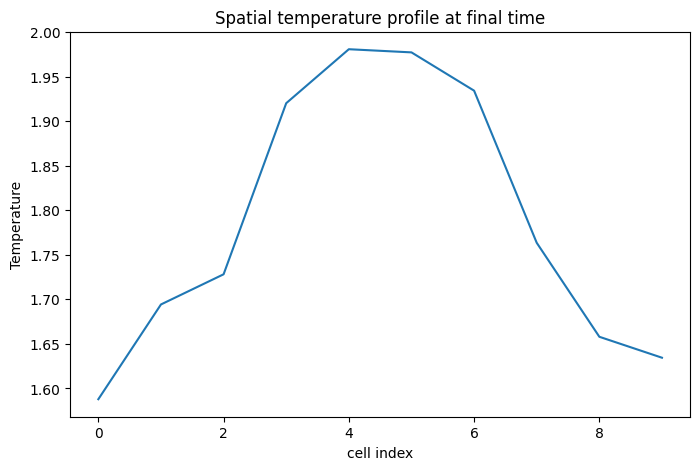

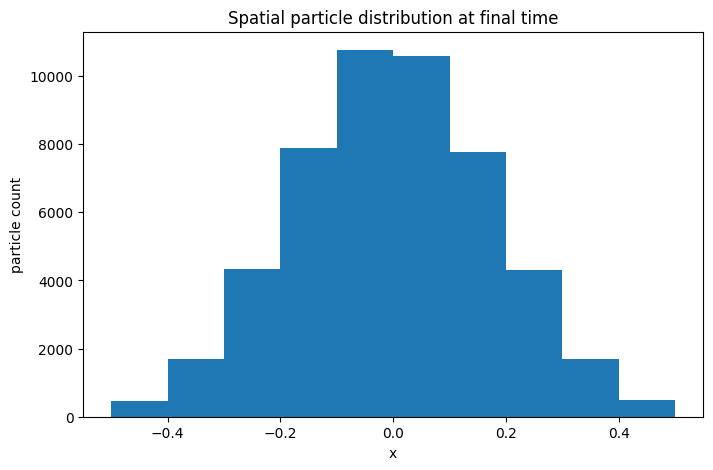

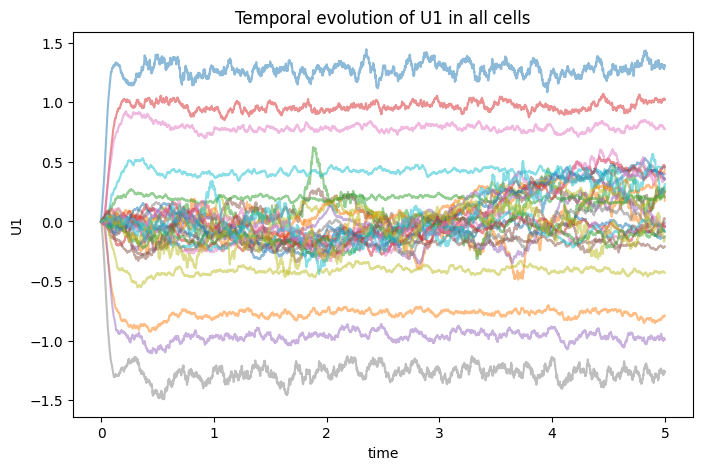

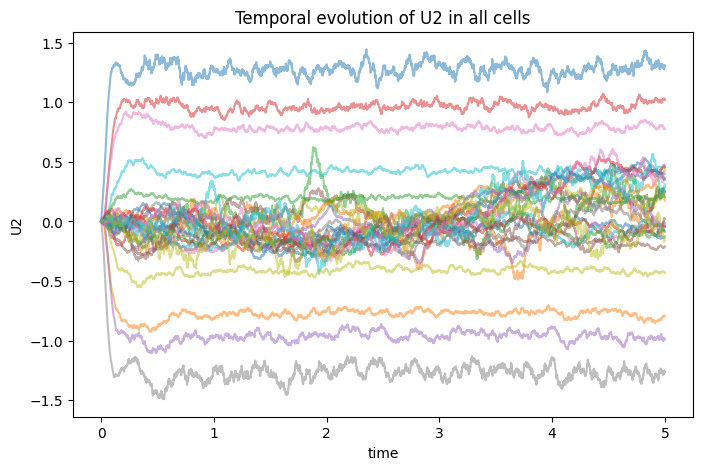

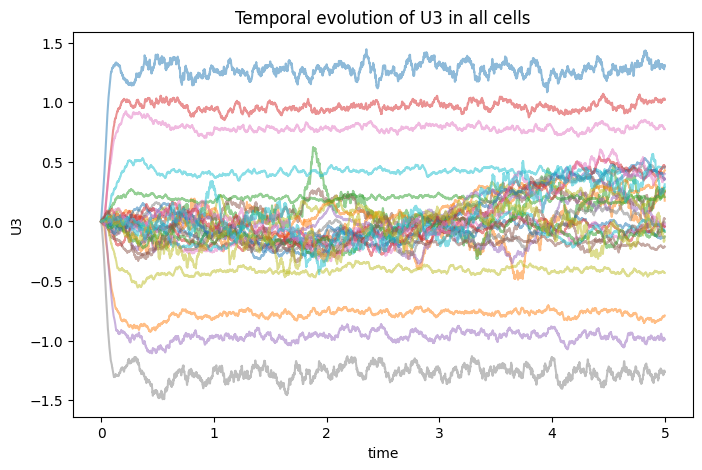

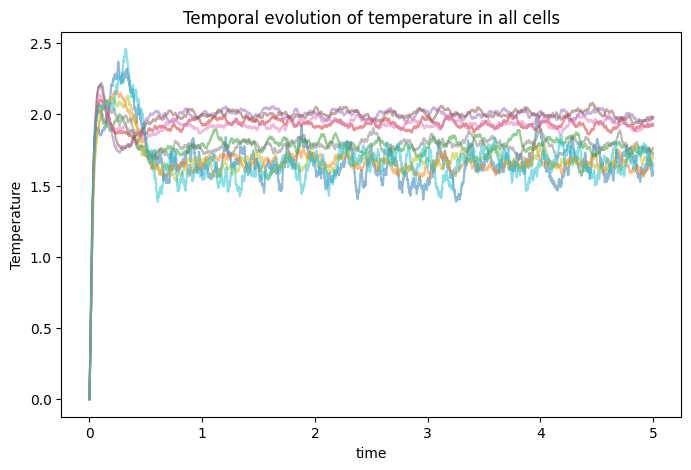

In [7]:
plt.figure(figsize=(8,5))
plt.plot(range(Nc), U[-1,:, 0], label='U1 final')
plt.plot(range(Nc), U[-1,:, 1], label='U2 final')
plt.plot(range(Nc), U[-1,:, 2], label='U3 final')
plt.legend()
plt.xlabel('cell index')
plt.ylabel('mean velocity')
plt.title('Spatial velocity profile at final time')
plt.show()

plt.figure(figsize=(8,5))
plt.plot(range(Nc), T[-1,:])
plt.xlabel('cell index')
plt.ylabel('Temperature')
plt.title('Spatial temperature profile at final time')
plt.show()

plt.figure(figsize=(8,5))
plt.hist(X, bins=Nc)
plt.xlabel('x')
plt.ylabel('particle count')
plt.title('Spatial particle distribution at final time')
plt.show()


plt.figure(figsize=(8,5))
for c in range(Nc):
    plt.plot(np.arange(Nsteps)*dt, U[:,c], alpha=0.5)
plt.xlabel('time')
plt.ylabel('U1')
plt.title('Temporal evolution of U1 in all cells')
plt.show()

plt.figure(figsize=(8,5))
for c in range(Nc):
    plt.plot(np.arange(Nsteps)*dt, U[:,c], alpha=0.5)
plt.xlabel('time')
plt.ylabel('U2')
plt.title('Temporal evolution of U2 in all cells')
plt.show()

plt.figure(figsize=(8,5))
for c in range(Nc):
    plt.plot(np.arange(Nsteps)*dt, U[:,c], alpha=0.5)
plt.xlabel('time')
plt.ylabel('U3')
plt.title('Temporal evolution of U3 in all cells')
plt.show()

plt.figure(figsize=(8,5))
for c in range(Nc):
    plt.plot(np.arange(Nsteps)*dt, T[:,c], alpha=0.5)
plt.xlabel('time')
plt.ylabel('Temperature')
plt.title('Temporal evolution of temperature in all cells')
plt.show()